<a href="https://colab.research.google.com/github/shanmukh-29/my-first-repo/blob/main/MiniProject_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
df=pd.read_csv('/ai_learning_lab.csv')
df=df.drop_duplicates()
df.student_name=df.student_name.str.strip()
df.topic=df.topic.str.strip()
df.tool_used=df.tool_used.str.strip()
df.attendance = df.attendance.str.title()
df.lab_completed = df.lab_completed.str.title()
df.api_used = df.api_used.str.title()
df.loc[(df['assignment_score'] < 0) | (df['assignment_score'] > 100), 'assignment_score'] = pd.NA
df.loc[(df['quiz_score']<0) | (df['quiz_score']>100),'quiz_score']=pd.NA
df.loc[df['study_hours']<0,'study_hours']=pd.NA
df.loc[(df['feedback_rating']<0) | (df['feedback_rating']>5),'feedback_rating']=pd.NA
df.assignment_score=df.assignment_score.fillna(df.assignment_score.mean())
df.quiz_score=df.quiz_score.fillna(df.quiz_score.mean())
df.study_hours=df.study_hours.fillna(df.study_hours.median())
df.feedback_rating=df.feedback_rating.fillna(df.feedback_rating.median())
print(df.shape)
print(df.isna().sum())
df.to_csv('cleaned_ai_learning_lab.csv', index=False)
display(df.head())

(105, 12)
student_id          0
student_name        0
batch               0
topic               0
attendance          0
assignment_score    0
quiz_score          0
lab_completed       0
study_hours         0
feedback_rating     0
tool_used           0
api_used            0
dtype: int64


,student_id,student_name,batch,topic,attendance,assignment_score,quiz_score,lab_completed,study_hours,feedback_rating,tool_used,api_used
0,ST001,Rakesh P,AIML-2603,JSON,Present,66.855556,63.208791,Yes,8.60,3.0,VS Code,No
1,ST002,Aarav Sharma,AIML-2602,SQL Basics,Absent,68.000000,65.000000,No,9.80,4.0,colab,Yes
2,ST003,Harsha Vardhan,AIML-2605,EDA,Present,35.000000,68.000000,No,4.70,3.0,colab,Yes
3,ST004,Sirisha P,AIML-2605,eda,Present,96.000000,27.000000,Yes,6.05,3.0,jupyter,Yes
4,ST005,Yashwanth K,AIML-2603,NumPy Basics,Absent,56.000000,94.000000,Yes,4.70,4.0,Jupyter,No


In [63]:
df=pd.read_csv('cleaned_ai_learning_lab.csv')
df['total_score']=df['assignment_score']+df['quiz_score']

def get_performance_level(score):
    if score >= 160:
        return 'Excellent'
    elif 120 <= score <= 159:
        return 'Good'
    elif 80 <= score <= 119:
        return 'Average'
    else:
        return 'Needs Support'

df['performance_level'] = df['total_score'].apply(get_performance_level)
print(df.assignment_score.mean())
print(df.quiz_score.mean())
print(df.study_hours.median())
print(25*'*')
print(df.groupby('performance_level').size())
print(25*'*')
print(df.groupby('topic').total_score.mean())
print(25*'*')
print(df.groupby('batch').total_score.mean())
print(25*'*')
print(df['student_name'][df['performance_level']=='Needs Support'])

66.85555555555555
63.20879120879121
6.05
*************************
performance_level
Average          33
Excellent        14
Good             54
Needs Support     4
dtype: int64
*************************
topic
AI Landscape        133.641758
APIs and Ethics     127.508043
Data Collections    136.766087
Decision Making     121.552198
EDA                 128.841758
File Handling       115.069597
Functions           108.783980
JSON                112.012869
Loops               141.977546
Matplotlib          162.713889
NumPy Basics        151.927778
Pandas Filtering    122.601256
Pandas Grouping     135.971111
Pandas Loading      121.000000
Python Basics       142.909992
SQL Basics          131.500000
SQL basics          123.463889
eda                 123.534142
pandas loading      122.912088
Name: total_score, dtype: float64
*************************
batch
AIML-2601    135.736013
AIML-2602    127.816874
AIML-2603    127.810295
AIML-2604    138.802391
AIML-2605    117.348230
Name: total_sco

/tmp/ipykernel_1787/1362743486.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_score', y='topic', data=average_score_by_topic, palette='viridis')


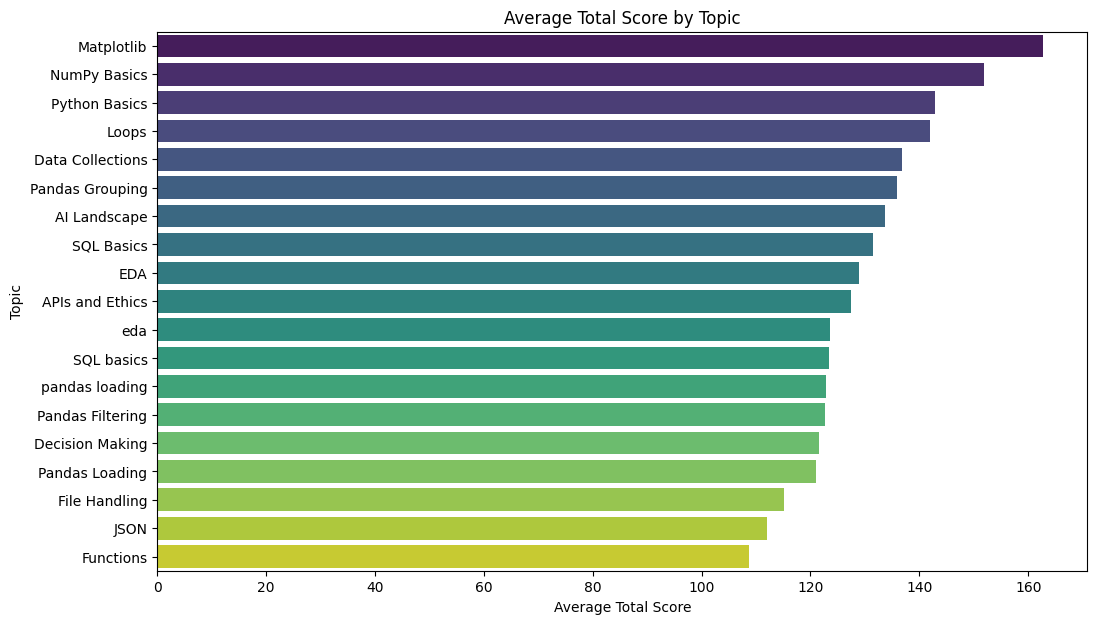

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('cleaned_ai_learning_lab.csv')
df['total_score']=df['assignment_score']+df['quiz_score']

average_score_by_topic = df.groupby('topic')['total_score'].mean().reset_index()

average_score_by_topic = average_score_by_topic.sort_values(by='total_score', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='total_score', y='topic', data=average_score_by_topic, palette='viridis')
plt.title('Average Total Score by Topic')
plt.xlabel('Average Total Score')
plt.ylabel('Topic')
plt.show()